In [1]:
import pandas as pd
import numpy as np
import xailib.xailib_base

from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from xailib.data_loaders.dataframe_loader import prepare_dataframe

from xailib.explainers.lime_explainer import LimeXAITabularExplainer
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer
from lore_explainer.explanation import ExplanationEncoder
from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper

import altair as alt
import json
import matplotlib.pyplot as plt

import os

In [2]:
from plot_explanation import PlotExplanation

In [3]:
path = os.getcwd()
print(path)

/Users/eleonoracappuccio/xai-visualization_rules_fi/notebooks


In [3]:
datasets=['titanic_c.csv','german_credit.csv']

In [4]:
source_file = f'../datasets/{datasets[1]}'
class_field = 'default'
# Load and transform dataset
df = pd.read_csv(source_file, skipinitialspace=True, na_values='?', keep_default_na=True)

In [5]:
df, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df, class_field)

In [6]:
test_size = 0.3
random_state = 42
X_train_g, X_test_g, Y_train_g, Y_test_g= train_test_split(df[feature_names], df[class_field],
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=df[class_field])

In [7]:
bb= RandomForestClassifier(n_estimators=30, random_state=42)
bb.fit(X_train_g.values, Y_train_g.values)
bbox = sklearn_classifier_wrapper(bb)

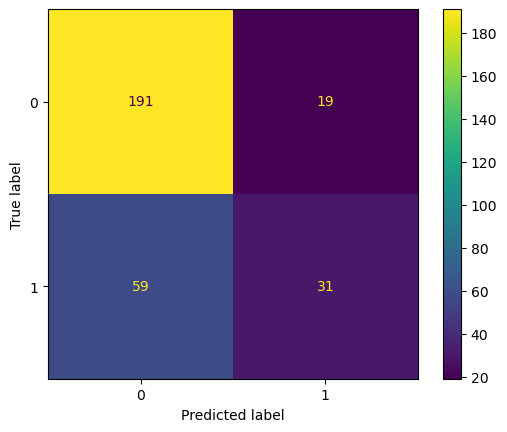

In [8]:
predictions = bb.predict(X_test_g)
cm = confusion_matrix(Y_test_g, predictions, labels=bb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bb.classes_)
disp.plot()
plt.show()

In [9]:
# Predict probabilities for the test set
probabilities = bb.predict_proba(X_test_g)
for index in range(0,200):
    # Example: Print the probability of the first test instance
    print("the index is", index)
    print("Predicted class for first test instance:", probabilities[index].argmax())
    print("Confidence of the prediction:", probabilities[index])
    print("True prediction:=", Y_test_g.iloc[index])
    print("Instance is :=", X_test_g.iloc[index].values )

the index is 0
Predicted class for first test instance: 0
Confidence of the prediction: [0.96666667 0.03333333]
True prediction:= 0
Instance is := [48 3578 4 1 47 1 1 False False False True False True False False False
 False False False False True False False False False False False False
 False False True True False False False False False False False True
 False False True False False True False False True False False True False
 False True False False False True False True]
the index is 1
Predicted class for first test instance: 0
Confidence of the prediction: [0.66666667 0.33333333]
True prediction:= 0
Instance is := [13 882 4 4 23 2 1 True False False False False True False False False
 False False False False True False False False False False False True
 False False False False True False False False False False False True
 False True False False False True False False True False False True False
 False True False False True False False True]
the index is 2
Predicted class for 

In [10]:
## SHAP explainer
s_explainer = ShapXAITabularExplainer(bbox, feature_names)
config = {'explainer': 'tree', 'X_train': X_train_g.iloc[0:].values}
s_explainer.fit(config)


l_explainer = LoreTabularExplainer(bbox)
config = {'neigh_type':'geneticp', 'size':1000, 'ocr':0.1, 'ngen':15}
l_explainer.fit(df, class_field, config)

In [11]:
class CustomJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.bool_):
            return bool(obj)
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.generic):
            return obj.item()  # For other numpy scalar types
        return super(CustomJSONEncoder, self).default(obj)

In [39]:
source_file = f'../datasets/{datasets[1]}'
class_field = 'default'
# Load and transform dataset
df_german = pd.read_csv(source_file, skipinitialspace=True, na_values='?', keep_default_na=True)

In [40]:
df_german.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   default                     1000 non-null   int64 
 1   account_check_status        1000 non-null   object
 2   duration_in_month           1000 non-null   int64 
 3   credit_history              1000 non-null   object
 4   purpose                     1000 non-null   object
 5   credit_amount               1000 non-null   int64 
 6   savings                     1000 non-null   object
 7   present_emp_since           1000 non-null   object
 8   installment_as_income_perc  1000 non-null   int64 
 9   personal_status_sex         1000 non-null   object
 10  other_debtors               1000 non-null   object
 11  present_res_since           1000 non-null   int64 
 12  property                    1000 non-null   object
 13  age                         1000 non-null   int64

In [54]:
df_german['foreign_worker'].unique()

array(['yes', 'no'], dtype=object)

In [57]:
categorical_features_info = {
    'account_check_status': {
        'is_ordinal': True,
        'order': ['no checking account', '< 0 DM', '0 <= ... < 200 DM','>= 200 DM / salary assignments for at least 1 year']  # Descendant order
    },
    'credit_history': {
        'is_ordinal': True,
        'order':['critical account/ other credits existing (not at this bank)','delay in paying off in the past','existing credits paid back duly till now','all credits at this bank paid back duly','no credits taken/ all credits paid back duly']
    },
        'purpose': {
        'is_ordinal': False
    },
        'savings': {
        'is_ordinal': True,
        'order': ['unknown/ no savings account', '... < 100 DM', '100 <= ... < 500 DM','500 <= ... < 1000 DM ','.. >= 1000 DM ']
    },
        'present_emp_since': {
        'is_ordinal': True,
        'order': ['unemployed', '... < 1 year ', '1 <= ... < 4 years','4 <= ... < 7 years','.. >= 7 years']
    },
        'personal_status_sex': {
        'is_ordinal': False
    },
        'other_debtors': {
        'is_ordinal': False
    },
        'property': {
        'is_ordinal': False
    },
        'other_installment_plans': {
        'is_ordinal': True,
        'order': ['None', 'bank', 'stores']
    },
        'housing': {
        'is_ordinal': True,
        'order': ['rent', 'for free', 'own']
    },

    'job': {
        'is_ordinal': False
    },
    
    'telephone': {
        'is_ordinal': False
    },
    'foreign_worker': {
        'is_ordinal': False
    },
}

In [72]:
def select_and_explain_instance(inst_num, l_explnr, s_explnr, path):
    inst = X_test_g.iloc[inst_num].values
    true_class = Y_test_g.iloc[inst_num]

    #check
    print('Instance ',inst)
    print('True class ',Y_test_g.iloc[inst_num])
    print('Predicted class ',bb.predict(inst.reshape(1, -1)))
    print('Predicted Probability', probabilities[inst_num])


    predicted_class = bb.predict(inst.reshape(1, -1))
    predicted_proba = bb.predict_proba(inst.reshape(1, -1))
    
    ## Feature Importance Explanation
    s_exp = s_explnr.explain(inst)
    shap_feature_importance = s_exp.exp
    l_exp = l_explnr.explain(inst)
    l_expDict = l_exp.expDict
    # remove key dt from expDict
    l_expDict.pop('dt', None)
    crules = l_expDict['crules']
    if len(crules)>0:
        print('Lore crules', len(crules))
    
    pe = PlotExplanation(
        feature_names=feature_names,
        real_feature_names=real_feature_names,
        instance_number=inst_num,
        x_train=X_train_g,
        expDict = l_expDict,
        feature_importance_type='shap',
        feature_importance=shap_feature_importance,
        numeric_columns=numeric_columns
    )
    rule_descr = pe.prepare_rule_descriptor()
    #add categorical info
    categorical_features_info = {
    'account_check_status': {
        'is_ordinal': True,
        'order': ['no checking account', '< 0 DM', '0 <= ... < 200 DM','>= 200 DM / salary assignments for at least 1 year']  # Descendant order
    },
    'credit_history': {
        'is_ordinal': True,
        'order':['critical account/ other credits existing (not at this bank)','delay in paying off in the past','existing credits paid back duly till now','all credits at this bank paid back duly','no credits taken/ all credits paid back duly']
    },
        'purpose': {
        'is_ordinal': False
    },
        'savings': {
        'is_ordinal': True,
        'order': ['unknown/ no savings account', '... < 100 DM', '100 <= ... < 500 DM','500 <= ... < 1000 DM ','.. >= 1000 DM ']
    },
        'present_emp_since': {
        'is_ordinal': True,
        'order': ['unemployed', '... < 1 year ', '1 <= ... < 4 years','4 <= ... < 7 years','.. >= 7 years']
    },
        'personal_status_sex': {
        'is_ordinal': False
    },
        'other_debtors': {
        'is_ordinal': False
    },
        'property': {
        'is_ordinal': False
    },
        'other_installment_plans': {
        'is_ordinal': True,
        'order': ['None', 'bank', 'stores']
    },
        'housing': {
        'is_ordinal': True,
        'order': ['rent', 'for free', 'own']
    },

    'job': {
        'is_ordinal': False
    },
    
    'telephone': {
        'is_ordinal': False
    },
    'foreign_worker': {
        'is_ordinal': False
    },
}



    for feature_entry in rule_descr["features"]:
        feature_name = feature_entry.get("rname")
        if feature_entry.get("type") == "categorical" and feature_name in categorical_features_info:
            feature_entry["is_ordinal"] = categorical_features_info[feature_name]["is_ordinal"]
            if feature_entry["is_ordinal"]:
                feature_entry["order"] = categorical_features_info[feature_name]["order"]
    output_data = {
        "rule_descr": rule_descr,
        "predicted_class": predicted_class[0],
        "true_class":int(true_class),
        "predicted_proba": predicted_proba[0].tolist()
        }
    

    with open(f'{path}/instance_{inst_num}.json', "w") as outfile:
        json.dump(output_data, outfile, cls=CustomJSONEncoder, indent=4)

    
    return inst

In [73]:
inst_num = 1

In [74]:
inst = X_test_g.iloc[inst_num].values
inst

array([13, 882, 4, 4, 23, 2, 1, True, False, False, False, False, True,
       False, False, False, False, False, False, False, True, False,
       False, False, False, False, False, True, False, False, False,
       False, True, False, False, False, False, False, False, True, False,
       True, False, False, False, True, False, False, True, False, False,
       True, False, False, True, False, False, True, False, False, True],
      dtype=object)

In [75]:
select_and_explain_instance(inst_num, l_explainer, s_explainer,'.')

Instance  [13 882 4 4 23 2 1 True False False False False True False False False
 False False False False True False False False False False False True
 False False False False True False False False False False False True
 False True False False False True False False True False False True False
 False True False False True False False True]
True class  0
Predicted class  [0]
Predicted Probability [0.66666667 0.33333333]
Lore crules 1


array([13, 882, 4, 4, 23, 2, 1, True, False, False, False, False, True,
       False, False, False, False, False, False, False, True, False,
       False, False, False, False, False, True, False, False, False,
       False, True, False, False, False, False, False, False, True, False,
       True, False, False, False, True, False, False, True, False, False,
       True, False, False, True, False, False, True, False, False, True],
      dtype=object)

#### Check

In [37]:
inst = X_test_g.iloc[inst_num].values
print('Instance ',inst)
print('True class ',Y_train_g.iloc[inst_num])
print('Predicted class ',bb.predict(inst.reshape(1, -1)))

Instance  [13 882 4 4 23 2 1 True False False False False True False False False
 False False False False True False False False False False False True
 False False False False True False False False False False False True
 False True False False False True False False True False False True False
 False True False False True False False True]
True class  0
Predicted class  [0]


In [19]:
Y_train_g.iloc[inst_num]

0

In [21]:
expDict = exp.expDict
# remove key dt from expDict
expDict.pop('dt', None)
expDict

NameError: name 'exp' is not defined

In [20]:
rules =exp.expDict['rule']
crules = exp.expDict['crules']
deltas = exp.expDict['deltas']

NameError: name 'exp' is not defined